In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats

warnings.filterwarnings("ignore")

az.style.use('arviz-darkgrid')
plt.style.use('ggplot')

g++ not available, if using conda: `conda install gxx`


# Bayesian Updates

In a real case scenario, we often do not have all the data at once, the data comes over time. To build a successful model, we need to update our model regularly.

There are different ways to do this. The most common one is refitting. For example, if we have sales data from January to March, in each upcoming month we refit the model using everything from January to the most recent month.

We can also do this in the Bayesian world, but alternatively we can use the posterior distributions as priors for the upcoming data.

## From Posterior to Prior

To use Bayesian updates, we need to have distributional parameters. These can easily be obtained through conjugate pairs since each parameter has an analytical formula to begin with. However, we cannot always use conjugate pairs. In those cases, we need to use MCMC methods, and the latter requires a more detailed assessment. We will cover each method subsequently.

### From Posterior to Prior Using Conjugate Pairs

Let's go over an example. We will use Beta Binomial conjugates to update the posterior distribution through different batches of binary data. We will start with a flat Beta prior, then each time we get the posterior we will use its parameters to define our next prior.

The Beta Binomial conjugate formulas are

$\theta \sim \text{Beta}(a, b)$

$y \sim \text{Binomial}(n, \theta)$

$\theta \mid y \sim \text{Beta}(a + y,\ b + n - y)$

where $y$ is the number of successes observed in $n$ trials.

**Example**

The parameters of the example are the following:

$\text{success rate: } 0.35$

$\text{number of data points in each batch: } n = 40$

$\text{number of batches: } k = 4$

$\text{first prior} \sim \text{Beta}(1,1)$


In [2]:
np.random.seed(42)

true_rate = 0.35
batch_size = 40
n_batches = 4

batches = np.random.binomial(1, true_rate, size = (n_batches, batch_size))

a, b = 1.0, 1.0
rows = []

for i, batch in enumerate(batches, start = 1):
    successes = batch.sum()
    a = a + successes
    b = b + batch_size - successes

    lower, upper = stats.beta.ppf([0.025, 0.975], a, b)
    rows.append({"batch": i,
                 "successes": successes,
                 "a": a,
                 "b": b,
                 "posterior_mean": a / (a + b),
                 "ci_low": lower,
                 "ci_high": upper})

pd.DataFrame(rows).round(3)

,batch,successes,a,b,posterior_mean,ci_low,ci_high
0,1,11,12.0,30.0,0.286,0.161,0.429
1,2,15,27.0,55.0,0.329,0.232,0.434
2,3,13,40.0,82.0,0.328,0.248,0.413
3,4,13,53.0,109.0,0.327,0.257,0.401


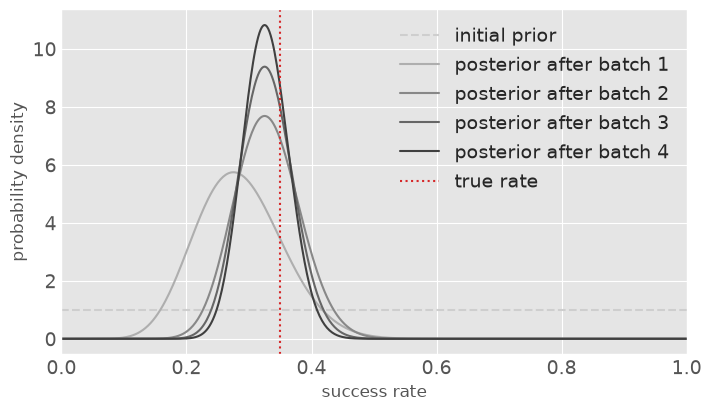

In [3]:
grid = np.linspace(0, 1, 500)
shades = plt.cm.Greys(np.linspace(0.3, 0.8, n_batches + 1))

fig, ax = plt.subplots(figsize = (7, 4))

running_a, running_b = 1.0, 1.0
ax.plot(grid, stats.beta.pdf(grid, running_a, running_b),
        color = shades[0], linestyle = "--", label = "initial prior")

for i, batch in enumerate(batches, start = 1):
    successes = batch.sum()
    running_a = running_a + successes
    running_b = running_b + batch_size - successes
    ax.plot(grid, stats.beta.pdf(grid, running_a, running_b),
            color = shades[i], label = f"posterior after batch {i}")

ax.axvline(true_rate, color = "tab:red", linestyle = ":", label = "true rate")
ax.set_xlabel("success rate")
ax.set_ylabel("probability density")
ax.set_xlim(0, 1)
ax.legend()
plt.show()


The dashed line shows our first prior. Notice how the posterior distributions become steeper around the true success rate. Moreover, the mode of the posterior starts away from the true rate, but over time the gap closes.

### From Posterior to Prior Using MCMC

As we discussed, to use Bayesian updates we need to somehow obtain the distributional parameters. The first way to accomplish this is to approximate the posterior with a well defined distribution. We will use the same example above, but this time to break conjugacy, we will use a Normal prior instead. Additionally, to map the prior onto the $0$ to $1$ range, we will use an inverse logit transformation.

In [4]:
with pm.Model() as first_batch_model:

    z = pm.Normal("z", mu = 0, sigma = 1.5)
    p = pm.Deterministic("p", pm.math.invlogit(z))

    likelihood = pm.Bernoulli("y_obs", p = p, observed = batches[0])

    trace = pm.sample(random_seed = 42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


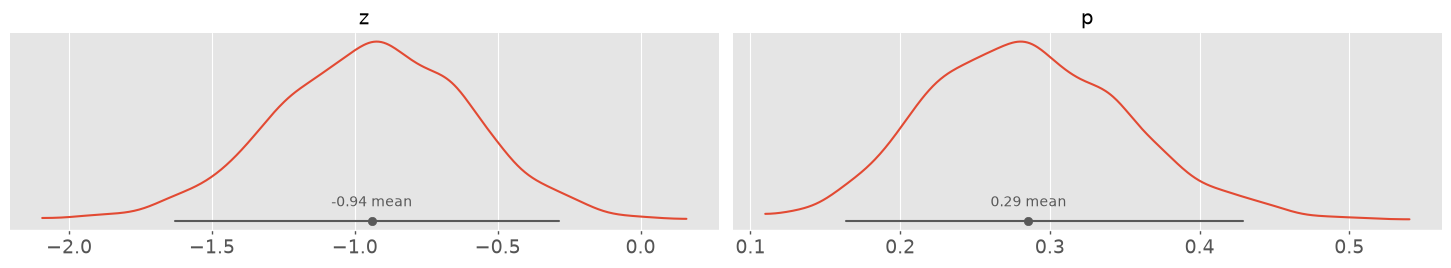

In [5]:
azp.plot_dist(trace, var_names = ["z", "p"], ci_prob = 0.95)

Now that we have the posterior, we can fit it to a known distribution. Since the Beta is the conjugate prior of the Binomial, we will try to fit the posterior to a Beta distribution.

In [6]:
p_samples = trace.posterior["p"].values.flatten()

fitted_a, fitted_b, _, _ = stats.beta.fit(p_samples, floc = 0, fscale = 1)

print("fitted Beta:", round(fitted_a, 3), round(fitted_b, 3))
print("conjugate  :", rows[0]["a"], rows[0]["b"])


fitted Beta: 12.457 31.14
conjugate  : 12.0 30.0


Notice how similar the results are to the parameters that we obtained in the first conjugate update. These two matched because we selected a similar prior, hence the posterior looks pretty similar to the one we obtained in the first conjugate update.

Now, since we have a conjugate pair, we can proceed with the remaining three updates using conjugate methods:

In [7]:
a, b = fitted_a, fitted_b
updated_rows = []

for i, batch in enumerate(batches[1:], start = 2):
    successes = batch.sum()
    a = a + successes
    b = b + batch_size - successes

    lower, upper = stats.beta.ppf([0.025, 0.975], a, b)
    updated_rows.append({"batch": i,
                         "successes": successes,
                         "a": a,
                         "b": b,
                         "posterior_mean": a / (a + b),
                         "ci_low": lower,
                         "ci_high": upper})

pd.DataFrame(updated_rows).round(3)

,batch,successes,a,b,posterior_mean,ci_low,ci_high
0,2,15,27.457,56.14,0.328,0.233,0.432
1,3,13,40.457,83.14,0.327,0.248,0.412
2,4,13,53.457,110.14,0.327,0.257,0.400


As you can see, we obtain a similar result.

There is an alternative way to obtain a prior from the posterior. The `pm.Interpolated` function takes a range of $x$ values and their corresponding posterior probability densities, then builds a distribution via interpolation. It is similar to the trapezoid rule. Let's see how it looks on the same example. We will use a range of $x$ values and their density values from the first batch posterior to obtain our prior.

In [8]:
p_grid = np.linspace(p_samples.min(), p_samples.max(), 200)
p_density = stats.gaussian_kde(p_samples)(p_grid)

with pm.Model() as interpolated_model:

    p = pm.Interpolated("p", p_grid, p_density)

    likelihood = pm.Bernoulli("y_obs", p = p, observed = batches[1])

    interpolated_trace = pm.sample(random_seed = 42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [9]:
print("interpolated prior:", round(interpolated_trace.posterior["p"].mean().item(), 3))
print("fitted Beta prior :", round(updated_rows[0]["posterior_mean"], 3))
print("conjugate route   :", round(rows[1]["posterior_mean"], 3))


interpolated prior: 0.329
fitted Beta prior : 0.328
conjugate route   : 0.329


Again, we obtained a similar result.

In conclusion, the Bayesian update is a versatile tool for probability updates since each data point is only evaluated once. It assumes there is no concept drift (the parameter does not change significantly over time). If there is one, intentionally eliminating stale data from the model is a wiser option.